# GEC Pretrained Classifier with 5-Fold Stratified Cross-Validation

In [2]:
import sys
from pathlib import Path

model_root = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

print(f'Added to sys.path: {model_root}')

Added to sys.path: /mnt/e/fyassine/ad-early-detection/MODEL


In [3]:
import json
import numpy as np
import os
import torch
import wandb
import pandas as pd
import seaborn as sns

from collections import OrderedDict
from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from torch_geometric.loader import DataLoader
from copy import deepcopy
from datetime import datetime

from model.GEC.dataset import ClassificationDataset, CombinedClassificationDataset
from model.GEC.models import GraphEncoderClassifierAttention
from model.GEC.utils import load_frozen_encoder_from_gaae, compute_class_weights
from model.GEC.utils import knn_binary_adjacency_matrix_no_diag
from model.GEC.train import train_classifier
sns.set(style="whitegrid")

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [5]:
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = "gec-converter-classification-dmn"

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
DMN_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/dmn_only_schaefer'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata'
GEC_SPLITS_DIR = os.path.join(METADATA_DIR, 'splits_gec')
TRAIN_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'train.csv')
VAL_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'val.csv')
TEST_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'test.csv')

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae_dmn'),
]

GEC_OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_gec_dmn')
os.makedirs(GEC_OUTPUT_DIR, exist_ok=True)
GEC_CHECKPOINT_SEARCH_DIRS = [GEC_OUTPUT_DIR]
USE_GEC_CHECKPOINT = False

IN_FEATURES = 46
HIDDEN_DIM = 46
LATENT_DIM = 32
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.5
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30

KNN_K = 8
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'dmn'
FILE_VARIANT = 'z_transformed'

FREEZE_ENCODER = False
CLASSIFICATION_THRESHOLD = 0.35

N_FOLDS = 5
RANDOM_STATE = 42

In [ ]:
checkpoint_candidates = sorted(
    [
        (run_dir.name, str(model_file), str(run_dir))
        for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
        for base_dir in [Path(checkpoint_dir)]
        if base_dir.is_dir()
        for run_dir in sorted(base_dir.iterdir())
        if run_dir.is_dir()
        for model_file in [run_dir / f"model_{run_dir.name}.pth"]
        if model_file.exists()
    ],
    key=lambda x: x[0],
)

if not checkpoint_candidates:
    raise FileNotFoundError(
        'No GAAE checkpoints found. Train MODEL/notebooks/GAAE_DELCODE_DMN.ipynb first.'
    )

print('Available GAAE checkpoints:')
for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
    print(f'  {i}: {run_name} ({run_dir})')

default_index = len(checkpoint_candidates) - 1
selected_run_index_text = input(f'Select a GAAE checkpoint by index [default {default_index}]: ').strip()
selected_run_index = default_index if selected_run_index_text == '' else int(selected_run_index_text)
if selected_run_index < 0 or selected_run_index >= len(checkpoint_candidates):
    raise IndexError(f'GAAE checkpoint index out of range: {selected_run_index}')

RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

run_config_path = Path(SELECTED_RUN_DIR) / 'run_config.json'
if run_config_path.exists():
    with open(run_config_path, 'r') as f:
        run_config = json.load(f)
    model_cfg = run_config.get('model_config', {})
    IN_FEATURES = int(model_cfg.get('in_features', IN_FEATURES))
    HIDDEN_DIM = int(model_cfg.get('hidden_size', HIDDEN_DIM))
    LATENT_DIM = int(model_cfg.get('latent_dim', LATENT_DIM))
    NUM_HEADS = int(model_cfg.get('attention_heads', NUM_HEADS))
    DROPOUT = float(model_cfg.get('dropout', DROPOUT))
    print(f"Loaded run config from {run_config_path}")

print(f'Using GAAE checkpoint: {GAAE_CHECKPOINT_PATH}')
print(f'Configured dims: in={IN_FEATURES}, latent={LATENT_DIM}, heads={NUM_HEADS}, dropout={DROPOUT}')

mode_input = input('Select GEC mode: [1] use existing GEC checkpoint, [2] train GEC (default: 2): ').strip().lower()
if mode_input in {'', '2', 't', 'train'}:
    USE_GEC_CHECKPOINT = False
elif mode_input in {'1', 'c', 'checkpoint'}:
    USE_GEC_CHECKPOINT = True
else:
    raise ValueError('Invalid GEC mode selection. Use 1/checkpoint or 2/train.')

print(f"GEC mode selected: {'checkpoint' if USE_GEC_CHECKPOINT else 'train'}")

if USE_GEC_CHECKPOINT:
    gec_checkpoint_candidates = sorted(
        [
            (run_dir.name, str(model_file), str(run_dir))
            for checkpoint_dir in GEC_CHECKPOINT_SEARCH_DIRS
            for base_dir in [Path(checkpoint_dir)]
            if base_dir.is_dir()
            for run_dir in sorted(base_dir.iterdir())
            if run_dir.is_dir()
            for model_file in sorted(run_dir.glob('best_model_fold*.pth'))
        ],
        key=lambda x: x[0],
    )

    if not gec_checkpoint_candidates:
        raise FileNotFoundError('No GEC checkpoints found. Switch to training mode to create one.')

    print('Available GEC checkpoints:')
    for i, (run_name, model_file, run_dir) in enumerate(gec_checkpoint_candidates):
        print(f'  {i}: {run_name} ({model_file})')

    default_gec_index = len(gec_checkpoint_candidates) - 1
    selected_gec_index_text = input(f'Select a GEC checkpoint by index [default {default_gec_index}]: ').strip()
    selected_gec_index = default_gec_index if selected_gec_index_text == '' else int(selected_gec_index_text)
    if selected_gec_index < 0 or selected_gec_index >= len(gec_checkpoint_candidates):
        raise IndexError(f'GEC checkpoint index out of range: {selected_gec_index}')

    GEC_RUN_NAME, GEC_CHECKPOINT_PATH, GEC_SELECTED_RUN_DIR = gec_checkpoint_candidates[selected_gec_index]
    run_artifact_dir = GEC_SELECTED_RUN_DIR
    active_run_dir = Path(run_artifact_dir)
    print(f'Using GEC checkpoint: {GEC_CHECKPOINT_PATH}')
    print(f'Using checkpoint artifact directory: {active_run_dir}')
else:
    GEC_RUN_NAME = None
    GEC_CHECKPOINT_PATH = None
    GEC_SELECTED_RUN_DIR = None

Available checkpoints:
  0: dark-blaze-8_2026-03-24_01-53-42 (/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_dmn/dark-blaze-8_2026-03-24_01-53-42)
Loaded run config from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_dmn/dark-blaze-8_2026-03-24_01-53-42/run_config.json
Using checkpoint: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_dmn/dark-blaze-8_2026-03-24_01-53-42/model_dark-blaze-8_2026-03-24_01-53-42.pth
Configured dims: in=46, latent=32, heads=2, dropout=0.5


In [8]:
if not os.path.exists(GAAE_CHECKPOINT_PATH):
    raise FileNotFoundError(f'Checkpoint not found: {GAAE_CHECKPOINT_PATH}')
print(f'Checkpoint ready: {GAAE_CHECKPOINT_PATH}')

Checkpoint ready: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_dmn/dark-blaze-8_2026-03-24_01-53-42/model_dark-blaze-8_2026-03-24_01-53-42.pth


## Load Datasets

In [9]:
split_paths = {
    'train': TRAIN_SPLIT_CSV,
    'val': VAL_SPLIT_CSV,
    'test': TEST_SPLIT_CSV,
}
split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}

required_cols = {'Repseudonym', 'diagnosis', 'converter_status', 'sex', 'age'}
for name, df in split_frames.items():
    missing = required_cols - set(df.columns)
    assert not missing, f"Split {name}.csv missing columns: {missing}"

all_splits_df = pd.concat(split_frames.values(), ignore_index=True)
all_splits_df = all_splits_df.drop_duplicates(subset=['Repseudonym'], keep='first')
all_splits_df['Repseudonym'] = all_splits_df['Repseudonym'].astype(str)

patient_info_df = all_splits_df[['Repseudonym', 'sex', 'age']].rename(
    columns={'Repseudonym': 'Pseudonym'}
).set_index('Pseudonym')

status_by_id = all_splits_df.set_index('Repseudonym')['converter_status'].to_dict()
converter_ids = sorted(pid for pid, status in status_by_id.items() if status == 1)
non_converter_ids = sorted(pid for pid, status in status_by_id.items() if status == 0)

import tempfile
patient_info_path = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False).name
patient_info_df.to_csv(patient_info_path)

converter_dataset = ClassificationDataset(
    root=DMN_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

mci_stable_dataset = ClassificationDataset(
    root=DMN_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=non_converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

print(f"Converter dataset size: {len(converter_dataset)}")
print(f"Non-converter dataset size: {len(mci_stable_dataset)}")

Converter dataset size: 196
Non-converter dataset size: 413


In [10]:
combined_dataset = CombinedClassificationDataset(converter_dataset, mci_stable_dataset)
all_labels = combined_dataset.get_labels()

print(f"\nCombined dataset:")
print(f"  Total samples: {len(combined_dataset)}")
print(f"  Converters: {sum(all_labels)} ({sum(all_labels)/len(all_labels)*100:.1f}%)")
print(f"  Non-converters: {len(all_labels) - sum(all_labels)} ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")


Combined dataset:
  Total samples: 609
  Converters: 196.0 (32.2%)
  Non-converters: 413.0 (67.8%)


## Load Splits from DMN Metadata CSVs

Train + validation IDs are used as the cross-validation pool.
Test IDs are used as the holdout set.

In [11]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
val_ids = set(split_frames['val']['Repseudonym'].astype(str))
test_ids = set(split_frames['test']['Repseudonym'].astype(str))

patient_to_indices = {}
for idx in range(len(combined_dataset)):
    patient_id = str(getattr(combined_dataset[idx], 'patient_id', ''))
    patient_to_indices.setdefault(patient_id, []).append(idx)

def get_split_indices(patient_ids):
    indices = []
    for pid in patient_ids:
        indices.extend(patient_to_indices.get(str(pid), []))
    return sorted(indices)

train_split_indices = get_split_indices(train_ids)
val_split_indices = get_split_indices(val_ids)
test_split_indices = get_split_indices(test_ids)

cv_indices = train_split_indices + val_split_indices
holdout_indices = test_split_indices

cv_labels = [all_labels[i] for i in cv_indices]
holdout_labels = [all_labels[i] for i in holdout_indices]

print('DMN Split Sizes (from metadata CSVs):')
print(f'  Train split: {len(train_split_indices)}')
print(f'  Validation split: {len(val_split_indices)}')
print(f'  Test split (holdout): {len(test_split_indices)}')

cv_pos = int(sum(cv_labels))
holdout_pos = int(sum(holdout_labels))
print(f"\nCV set: {len(cv_indices)} samples, {cv_pos} converters ({(cv_pos/len(cv_labels)*100) if cv_labels else 0:.1f}%)")
print(f"Holdout set: {len(holdout_indices)} samples, {holdout_pos} converters ({(holdout_pos/len(holdout_labels)*100) if holdout_labels else 0:.1f}%)")

DMN Split Sizes (from metadata CSVs):
  Train split: 177
  Validation split: 46
  Test split (holdout): 31

CV set: 223 samples, 172 converters (77.1%)
Holdout set: 31 samples, 24 converters (77.4%)


## 5-Fold Stratified Cross-Validation

In [ ]:
cv_results = {
    'fold': [],
    'val_loss': [],
    'val_auc': [],
    'val_sensitivity': [],
    'val_specificity': [],
    'val_f1': [],
    'best_threshold': [],
    'best_epoch': []
}

cv_histories = {
    'train_loss': [],
    'val_loss': [],
}

best_model_state = None
best_val_auc = 0.0
best_fold = -1
best_threshold_overall = float(CLASSIFICATION_THRESHOLD)

if USE_GEC_CHECKPOINT:
    if GEC_CHECKPOINT_PATH is None:
        raise RuntimeError('GEC checkpoint mode is enabled but no checkpoint path was selected.')

    checkpoint_obj = torch.load(GEC_CHECKPOINT_PATH, map_location=device)

    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN
    ).to(device)

    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()

    if isinstance(checkpoint_obj, torch.nn.Module):
        model = checkpoint_obj.to(device)
        best_model_state = model.state_dict()
    elif isinstance(checkpoint_obj, dict):
        if 'state_dict' in checkpoint_obj and isinstance(checkpoint_obj['state_dict'], dict):
            state_dict = checkpoint_obj['state_dict']
        elif 'model_state_dict' in checkpoint_obj and isinstance(checkpoint_obj['model_state_dict'], dict):
            state_dict = checkpoint_obj['model_state_dict']
        else:
            state_dict = checkpoint_obj
        model.load_state_dict(state_dict)
        best_model_state = state_dict
    else:
        raise TypeError('Unsupported GEC checkpoint format. Expected torch.nn.Module or state_dict.')

    model.eval()
    best_model = model

    run_summary_path = Path(GEC_SELECTED_RUN_DIR) / 'run_summary.json'
    cv_results_path = Path(GEC_SELECTED_RUN_DIR) / 'cv_results.json'

    if run_summary_path.exists():
        with open(run_summary_path, 'r') as f:
            run_summary = json.load(f)

        loaded_cv_results = run_summary.get('cv_results', {})
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        loaded_cv_histories = run_summary.get('cv_histories', {})
        if isinstance(loaded_cv_histories, dict):
            train_histories = loaded_cv_histories.get('train_loss', [])
            val_histories = loaded_cv_histories.get('val_loss', [])
            if isinstance(train_histories, list):
                cv_histories['train_loss'] = train_histories
            if isinstance(val_histories, list):
                cv_histories['val_loss'] = val_histories

        best_fold = int(run_summary.get('best_fold', best_fold))
        best_val_auc = float(run_summary.get('best_val_auc', best_val_auc))
        best_threshold_overall = float(run_summary.get('best_threshold', best_threshold_overall))
    elif cv_results_path.exists():
        with open(cv_results_path, 'r') as f:
            loaded_cv_results = json.load(f)
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        if len(cv_results['val_auc']) > 0:
            val_auc_arr = np.array(cv_results['val_auc'], dtype=float)
            best_idx = int(np.argmax(val_auc_arr))
            best_val_auc = float(val_auc_arr[best_idx])
            if len(cv_results['fold']) > best_idx:
                best_fold = int(cv_results['fold'][best_idx])

        if len(cv_results['best_threshold']) > 0:
            best_threshold_overall = float(np.mean(np.array(cv_results['best_threshold'], dtype=float)))

    print(f'Loaded GEC checkpoint from {GEC_CHECKPOINT_PATH}')
    print('Cross-validation skipped because checkpoint mode is enabled')
else:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f"Starting {N_FOLDS}-fold stratified cross-validation...")
    print("=" * 60)

    for fold, (train_idx_in_cv, val_idx_in_cv) in enumerate(skf.split(cv_indices, cv_labels)):
        print(f"\n{'='*60}")
        print(f"FOLD {fold + 1}/{N_FOLDS}")
        print(f"{'='*60}")

        train_idx = [cv_indices[i] for i in train_idx_in_cv]
        val_idx = [cv_indices[i] for i in val_idx_in_cv]

        train_labels_fold = [all_labels[i] for i in train_idx]
        val_labels_fold = [all_labels[i] for i in val_idx]

        print(f"Train: {len(train_idx)} samples, {sum(train_labels_fold)} converters ({sum(train_labels_fold)/len(train_labels_fold)*100:.1f}%)")
        print(f"Val: {len(val_idx)} samples, {sum(val_labels_fold)} converters ({sum(val_labels_fold)/len(val_labels_fold)*100:.1f}%)")

        train_dataset = torch.utils.data.Subset(combined_dataset, train_idx)
        val_dataset = torch.utils.data.Subset(combined_dataset, val_idx)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        pos_weight = compute_class_weights(train_labels_fold, device=device)

        model = GraphEncoderClassifierAttention(
            in_features=IN_FEATURES,
            hidden_dim=HIDDEN_DIM,
            latent_dim=LATENT_DIM,
            cond_dim=COND_DIM,
            num_heads=NUM_HEADS,
            dropout=DROPOUT,
            classifier_hidden=CLASSIFIER_HIDDEN
        ).to(device)

        model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)

        if not FREEZE_ENCODER:
            model.unfreeze_encoder()

        optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)

        fold_model_state, history = train_classifier(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            device=device,
            pos_weight=pos_weight,
            epochs=EPOCHS,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            model_save_path=None,
            project_name=WANDB_PROJECT
        )

        model.load_state_dict(fold_model_state)
        model.eval()

        all_preds = []
        all_targets = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                cond_vec = torch.stack([
                    batch.patient_age,
                    batch.patient_sex.float()
                ], dim=1).to(device)
                output, _ = model(batch.x, batch.edge_index, cond_vec, batch.batch)
                probs = torch.sigmoid(output).cpu().numpy()
                all_preds.extend(probs.flatten())
                all_targets.extend(batch.is_converter.cpu().numpy().flatten())

        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)

        fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
        fold_auc = auc(fpr, tpr)

        j_scores = tpr - fpr
        best_threshold_idx = np.argmax(j_scores)
        best_threshold = thresholds[best_threshold_idx]

        binary_preds = (all_preds >= best_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(all_targets, binary_preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

        cv_results['fold'].append(fold + 1)
        cv_results['val_auc'].append(fold_auc)
        cv_results['val_sensitivity'].append(sensitivity)
        cv_results['val_specificity'].append(specificity)
        cv_results['val_f1'].append(f1)
        cv_results['best_threshold'].append(best_threshold)
        cv_results['best_epoch'].append(len(history['train_loss']))
        cv_histories['train_loss'].append(list(history.get('train_loss', [])))
        cv_histories['val_loss'].append(list(history.get('val_loss', [])))

        print(f"\nFold {fold+1} Results:")
        print(f"  AUC: {fold_auc:.4f}")
        print(f"  Sensitivity: {sensitivity:.4f}")
        print(f"  Specificity: {specificity:.4f}")
        print(f"  F1: {f1:.4f}")
        print(f"  Best Threshold: {best_threshold:.4f}")

        if fold_auc > best_val_auc:
            best_val_auc = fold_auc
            best_model_state = deepcopy(fold_model_state)
            best_fold = fold + 1
            best_threshold_overall = float(best_threshold)

        try:
            wandb.finish()
        except Exception:
            pass

    if best_model_state is not None:
        best_model = GraphEncoderClassifierAttention(
            in_features=IN_FEATURES,
            hidden_dim=HIDDEN_DIM,
            latent_dim=LATENT_DIM,
            cond_dim=COND_DIM,
            num_heads=NUM_HEADS,
            dropout=DROPOUT,
            classifier_hidden=CLASSIFIER_HIDDEN
        ).to(device)
        best_model = load_frozen_encoder_from_gaae(best_model, GAAE_CHECKPOINT_PATH, device=device)
        if not FREEZE_ENCODER:
            best_model.unfreeze_encoder()
        best_model.load_state_dict(best_model_state)
        best_model.eval()

    print(f"\n{'='*60}")
    print("CROSS-VALIDATION COMPLETE")
    print(f"{'='*60}")

Starting 5-fold stratified cross-validation...

FOLD 1/5
Train: 178 samples, 137.0 converters (77.0%)
Val: 45 samples, 35.0 converters (77.8%)
Loaded 36 pretrained encoder parameters from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_dmn/dark-blaze-8_2026-03-24_01-53-42/model_dark-blaze-8_2026-03-24_01-53-42.pth


/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 1 Results:
  AUC: 0.5514
  Sensitivity: 0.6857
  Specificity: 0.7000
  F1: 0.7742
  Best Threshold: 0.6253


learning_rate,███████▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁
train_acc,▄▂▁▁▁▂▃▃▄▆▆▆▅▆▇▆▇▇▇▇█▇█▇█
train_auc,▂▂▂▁▂▃▆▅▆▇█▆▇▆▇▇▇▇▇▇█████
train_f1,▅▃▁▂▂▂▃▃▅▆▇▆▆▇▇▆▇▇▇▇█▇█▇█
train_loss,█▆▅▆▆▆▄▅▄▃▃▃▃▅▃▂▂▅▃▂▁▁▁▃▃
val_acc,█▅▅▅▃▅▄▄▅▃▆▂▆▆▁▁▃▆▂▃▄▃▁▄▆
val_auc,█▁▁▃▅▇▆▇▆▅▅▄▄▄▄▄▄▅▅▅▅▅▅▆▆
val_f1,█▅▅▅▂▄▃▃▄▂▆▂▆▆▁▁▃▆▂▂▄▃▁▄▅
val_loss,▃▂▂▂▁▁▁▄▅▅▇▅▆▇▄▅▆█▅▅▆▅▆▇▇
learning_rate,0.00013
train_acc,0.86517


...

/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 5 Results:
  AUC: 0.5088
  Sensitivity: 0.7647
  Specificity: 0.4000
  F1: 0.7879
  Best Threshold: 0.6244


learning_rate,██████████▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁
train_acc,▆▃▁▄▄▄▄▄▃▅▆▅▆▆▇▇▇▇▇█▇▇█▇▇
train_auc,▂▂▂▁▂▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇██▇█
train_f1,▇▄▁▅▅▅▄▄▃▅▆▅▇▇▇▇▇▇▇█▇██▇▇
train_loss,█▇▇█▇▇▇▇▆▆▅▅▄▅▄▃▂▃▂▂▃▁▂▂▁
val_acc,█▁▆█▇▆▇▅▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_auc,▂▅▆██▇▇█▆▅▆▅▆▁▂▂▂▂▃▃▂▃▃▃▃
val_f1,█▁▇█▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_loss,▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▇▇▇▇▇███
learning_rate,0.00013
train_acc,0.82123



CROSS-VALIDATION COMPLETE


## Cross-Validation Results Summary

In [13]:
print("\nCross-Validation Summary:")
print("="*60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f"\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}")
print(f"Best threshold: {best_threshold_overall:.4f}")


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.5805     0.0570     0.5088     0.6676
val_sensitivity          0.7550     0.1870     0.4412     0.9714
val_specificity          0.5709     0.2518     0.3000     1.0000
val_f1                   0.7885     0.0997     0.6122     0.8947

Best model from Fold 4 with AUC = 0.6676
Best threshold: 0.9326


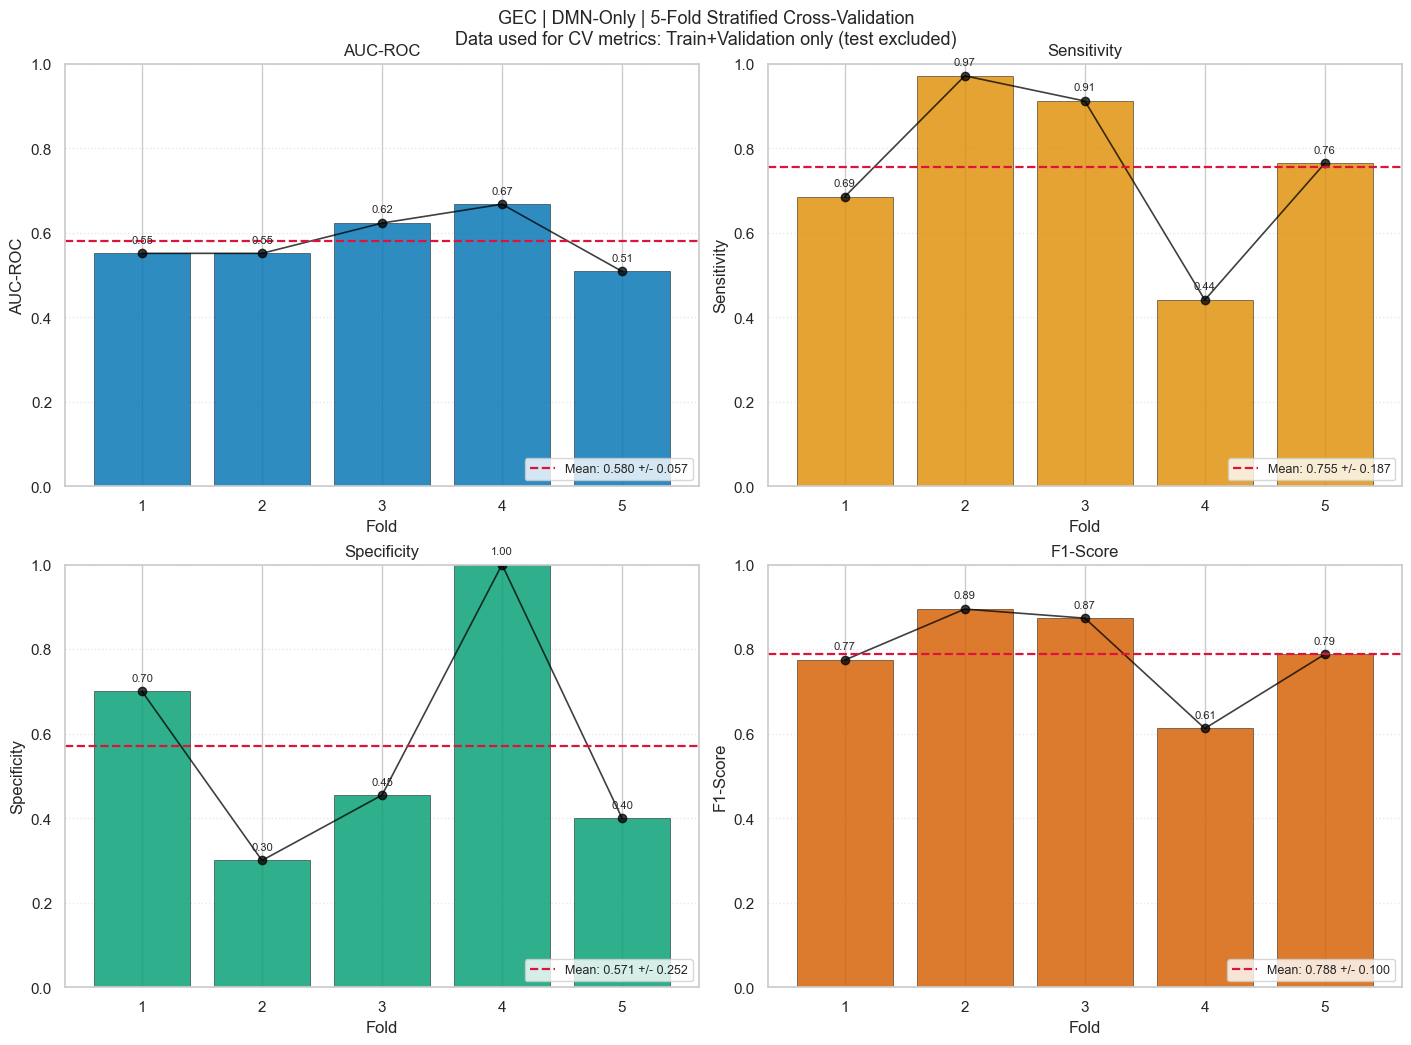

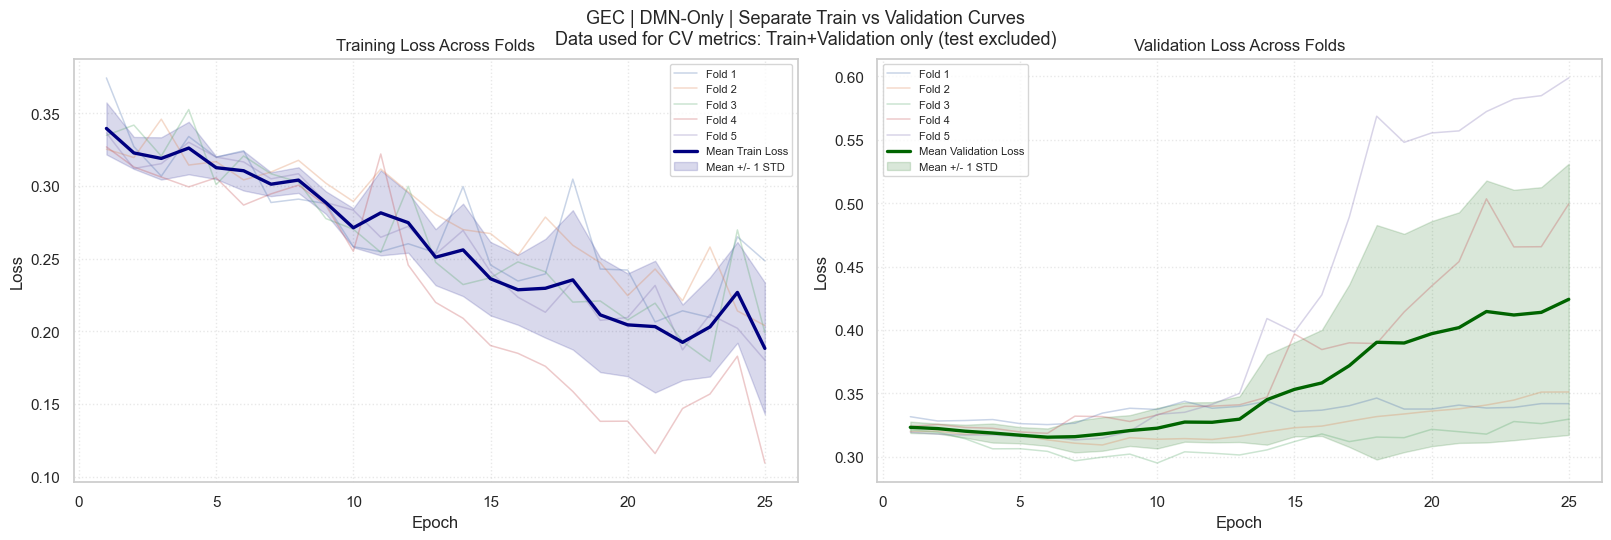

In [ ]:
region_label = 'DMN-Only' if str(CORRELATION_TYPE).lower() == 'dmn' else 'Whole-Brain'
model_label = 'GEC'
data_scope_label = 'Data used for CV metrics: Train+Validation only'

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']
colors = sns.color_palette('colorblind', len(metrics))

for ax, metric, title, color in zip(axes.flat, metrics, titles, colors):
    values = np.array(cv_results[metric], dtype=float)
    fold_x = np.arange(1, len(values) + 1)
    mean_val = float(np.mean(values))
    std_val = float(np.std(values))

    bars = ax.bar(fold_x, values, color=color, alpha=0.82, edgecolor='black', linewidth=0.4)
    ax.plot(fold_x, values, color='black', marker='o', linewidth=1.2, alpha=0.75)
    ax.axhline(y=mean_val, color='crimson', linestyle='--', linewidth=1.6, label=f'Mean: {mean_val:.3f} +/- {std_val:.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(fold_x)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle=':', alpha=0.45)
    ax.legend(loc='lower right', fontsize=9)

    for rect, val in zip(bars, values):
        ax.text(rect.get_x() + rect.get_width() / 2.0, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle(
    f'{model_label} | {region_label} | 5-Fold Stratified Cross-Validation\n{data_scope_label}',
    fontsize=13,
    y=1.03,
)
plt.show()

train_histories = [np.array(h, dtype=float) for h in cv_histories.get('train_loss', []) if len(h) > 0]
val_histories = [np.array(h, dtype=float) for h in cv_histories.get('val_loss', []) if len(h) > 0]

if train_histories and val_histories:
    max_train_len = max(len(h) for h in train_histories)
    max_val_len = max(len(h) for h in val_histories)

    train_mat = np.full((len(train_histories), max_train_len), np.nan, dtype=float)
    val_mat = np.full((len(val_histories), max_val_len), np.nan, dtype=float)

    for i, h in enumerate(train_histories):
        train_mat[i, :len(h)] = h
    for i, h in enumerate(val_histories):
        val_mat[i, :len(h)] = h

    train_mean = np.nanmean(train_mat, axis=0)
    train_std = np.nanstd(train_mat, axis=0)
    val_mean = np.nanmean(val_mat, axis=0)
    val_std = np.nanstd(val_mat, axis=0)

    epoch_train = np.arange(1, max_train_len + 1)
    epoch_val = np.arange(1, max_val_len + 1)

    fig2, ax2 = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    for fold_i, h in enumerate(train_histories, start=1):
        ax2[0].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[0].plot(epoch_train, train_mean, color='navy', linewidth=2.4, label='Mean Train Loss')
    ax2[0].fill_between(epoch_train, train_mean - train_std, train_mean + train_std, color='navy', alpha=0.15, label='Mean +/- 1 STD')
    ax2[0].set_title('Training Loss Across Folds')
    ax2[0].set_xlabel('Epoch')
    ax2[0].set_ylabel('Loss')
    ax2[0].grid(linestyle=':', alpha=0.45)
    ax2[0].legend(fontsize=8)

    for fold_i, h in enumerate(val_histories, start=1):
        ax2[1].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[1].plot(epoch_val, val_mean, color='darkgreen', linewidth=2.4, label='Mean Validation Loss')
    ax2[1].fill_between(epoch_val, val_mean - val_std, val_mean + val_std, color='darkgreen', alpha=0.15, label='Mean +/- 1 STD')
    ax2[1].set_title('Validation Loss Across Folds')
    ax2[1].set_xlabel('Epoch')
    ax2[1].set_ylabel('Loss')
    ax2[1].grid(linestyle=':', alpha=0.45)
    ax2[1].legend(fontsize=8)

    fig2.suptitle(
        f'{model_label} | {region_label} | Separate Train vs Validation Curves\n{data_scope_label}',
        fontsize=13,
        y=1.05,
    )
    plt.show()
else:
    print('No train/validation history found. Run cross-validation cell before plotting loss curves.')

## Save Best Model and Results

In [ ]:
if USE_GEC_CHECKPOINT:
    if GEC_SELECTED_RUN_DIR is None:
        raise RuntimeError('GEC checkpoint mode is enabled but no checkpoint run directory was selected.')
    run_artifact_dir = str(GEC_SELECTED_RUN_DIR)
    active_run_dir = Path(run_artifact_dir)
    run_name = active_run_dir.name
    print(f'Checkpoint mode active. Reusing existing run directory: {run_artifact_dir}')
else:
    if best_model_state is None:
        raise RuntimeError('No trained GEC model state found to save. Run training first.')

    run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    try:
        wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else 'cv_run'
    except Exception:
        wandb_run_name = 'cv_run'
    wandb_run_name = str(wandb_run_name).replace(' ', '-')
    run_name = f'{wandb_run_name}_{run_timestamp}'

    run_artifact_dir = os.path.join(GEC_OUTPUT_DIR, run_name)
    os.makedirs(run_artifact_dir, exist_ok=True)
    active_run_dir = Path(run_artifact_dir)

    model_filename = f'best_model_fold{best_fold}.pth'
    model_file = os.path.join(run_artifact_dir, model_filename)
    torch.save(best_model_state, model_file)
    print(f'Saved best model to {model_file}')

    cv_results_serializable = {
        k: [float(v) for v in vals] for k, vals in cv_results.items() if isinstance(vals, list)
    }
    results_file = os.path.join(run_artifact_dir, 'cv_results.json')
    with open(results_file, 'w') as f:
        json.dump(cv_results_serializable, f, indent=2)
    print(f'Saved CV results to {results_file}')

    run_summary = {
        'run_name': run_name,
        'timestamp': run_timestamp,
        'n_folds': N_FOLDS,
        'best_fold': int(best_fold),
        'best_val_auc': float(best_val_auc),
        'best_threshold': float(best_threshold_overall),
        'cv_results': cv_results_serializable,
        'cv_histories': {
            'train_loss': cv_histories.get('train_loss', []),
            'val_loss': cv_histories.get('val_loss', []),
        },
        'config': {
            'in_features': IN_FEATURES,
            'hidden_dim': HIDDEN_DIM,
            'latent_dim': LATENT_DIM,
            'cond_dim': COND_DIM,
            'num_heads': NUM_HEADS,
            'dropout': DROPOUT,
            'classifier_hidden': CLASSIFIER_HIDDEN,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'epochs': EPOCHS,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE,
            'knn_k': KNN_K,
            'file_variant': FILE_VARIANT,
            'freeze_encoder': FREEZE_ENCODER,
            'gaae_checkpoint': GAAE_CHECKPOINT_PATH,
            'dmn_root': DMN_ROOT,
        },
    }
    summary_file = os.path.join(run_artifact_dir, 'run_summary.json')
    with open(summary_file, 'w') as f:
        json.dump(run_summary, f, indent=2)
    print(f'Saved run summary to {summary_file}')

print(f'Active artifact directory: {active_run_dir}')

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_dmn/cv_run_2026-03-24_08-46-17/best_model_fold4.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_dmn/cv_run_2026-03-24_08-46-17/cv_results.json

Use this checkpoint directory for testing: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_dmn/cv_run_2026-03-24_08-46-17


## Robustness Evaluation (Threshold from Trained Classifier)

Using evaluation threshold: 0.932563
Selected Top-5 non-converter correctly predicted samples:
 DatasetIndex PatientID  Probability   Margin
          580 f328caa31     0.035402 0.897162
          299 41a2ff167     0.465310 0.467253
          404 834fb0636     0.566433 0.366130
          440 95c562d3e     0.728835 0.203728
          239 1b349d5ca     0.772923 0.159640


/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


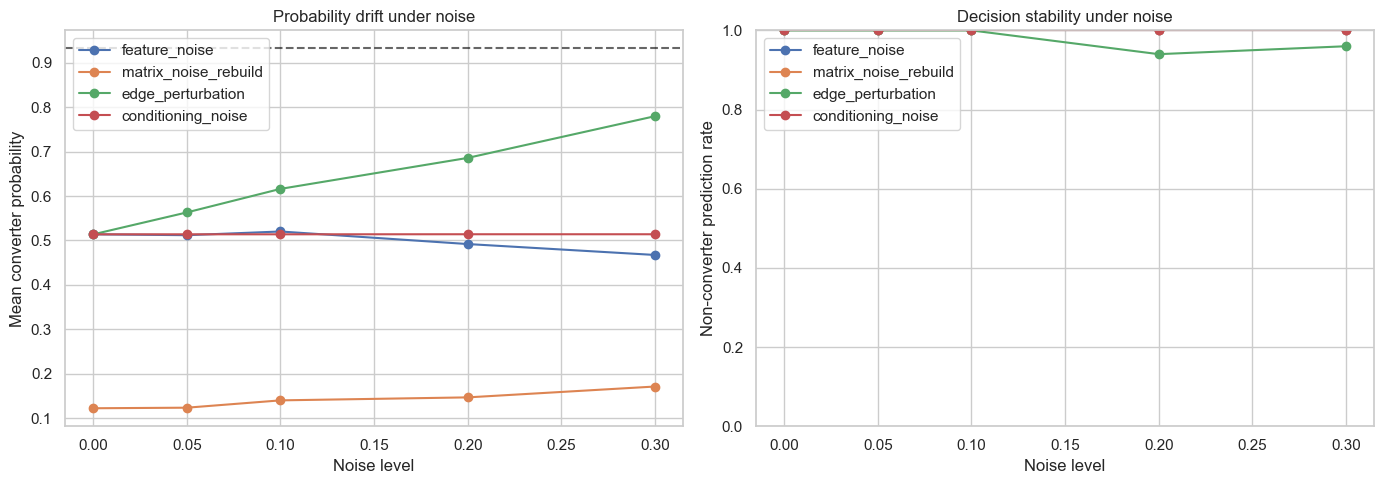

Saved evaluation artifacts to: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_dmn/cv_run_2026-03-24_08-46-17/robustness_eval_2026-03-24_08-46-21


In [ ]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.metrics import roc_curve, roc_auc_score
from model.GAAE.utils import calculate_dense_adjacency

np.random.seed(42)
torch.manual_seed(42)

if 'best_model' in globals() and best_model is not None:
    eval_model = best_model
elif 'model' in globals() and model is not None:
    eval_model = model
else:
    raise RuntimeError('No trained model found. Run training/checkpoint loading cells first.')

eval_model = eval_model.to(device)
eval_model.eval()

if 'val_errors_df' not in globals():
    raise RuntimeError('val_errors_df is missing. Run the cohort reconstruction error cell first.')
if 'test_dataset' not in globals():
    raise RuntimeError('test_dataset is missing. Run dataset loading cells first.')
if 'adjacency_args' not in globals():
    raise RuntimeError('adjacency_args is missing. Run configuration cells first.')

if 'subject_cohort_map' in globals() and isinstance(subject_cohort_map, dict):
    subject_cohort_map_all = dict(subject_cohort_map)
else:
    subject_cohort_map_all = {}
if 'test_csv' in globals():
    test_split_df = pd.read_csv(test_csv)
    test_map = (
        test_split_df[['Repseudonym', 'diagnosis']]
        .dropna()
        .drop_duplicates(subset=['Repseudonym'], keep='first')
        .assign(
            Repseudonym=lambda d: d['Repseudonym'].astype(str),
            diagnosis=lambda d: d['diagnosis'].astype(str).str.lower().str.strip(),
        )
        .set_index('Repseudonym')['diagnosis']
        .to_dict()
    )
    subject_cohort_map_all.update(test_map)

def clone_sample(sample):
    cloned = sample.clone()
    if hasattr(cloned, 'x') and torch.is_tensor(cloned.x):
        cloned.x = cloned.x.clone()
    if hasattr(cloned, 'edge_index') and torch.is_tensor(cloned.edge_index):
        cloned.edge_index = cloned.edge_index.clone()
    if hasattr(cloned, 'edge_attr') and torch.is_tensor(cloned.edge_attr):
        cloned.edge_attr = cloned.edge_attr.clone()
    return cloned

def infer_total_error(sample, noise_method='none', noise_level=0.0):
    d = clone_sample(sample)
    if noise_method in {'feature_noise', 'matrix_noise_rebuild'} and noise_level > 0:
        base_std = float(d.x.std().item()) if d.x.numel() > 1 else 1.0
        d.x = d.x + torch.randn_like(d.x) * (base_std * noise_level)
    if noise_method == 'matrix_noise_rebuild':
        adj_bin = knn_binary_adjacency_matrix_no_diag(d.x.detach().cpu().numpy(), **adjacency_args)
        src, dst = np.where(adj_bin > 0)
        if len(src) == 0:
            src = np.arange(max(0, d.x.size(0) - 1))
            dst = src + 1
        edge_index = np.vstack([src, dst])
        d.edge_index = torch.tensor(edge_index, dtype=torch.long)
        if hasattr(d, 'edge_attr'):
            d.edge_attr = torch.ones(d.edge_index.size(1), dtype=torch.float32)
    if noise_method == 'edge_perturbation' and noise_level > 0:
        edge_index = d.edge_index.detach().cpu()
        num_edges = edge_index.size(1)
        keep = max(1, int(round(num_edges * (1.0 - noise_level))))
        keep_perm = torch.randperm(num_edges)[:keep]
        kept_edges = edge_index[:, keep_perm]
        add_count = int(round(num_edges * noise_level))
        n_nodes = d.x.size(0)
        if add_count > 0:
            new_src = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            new_dst = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            valid = new_src != new_dst
            new_src = new_src[valid]
            new_dst = new_dst[valid]
            if new_src.numel() > 0:
                add_edges = torch.stack([new_src, new_dst], dim=0)
                d.edge_index = torch.cat([kept_edges, add_edges], dim=1)
            else:
                d.edge_index = kept_edges
        else:
            d.edge_index = kept_edges
        if hasattr(d, 'edge_attr'):
            d.edge_attr = torch.ones(d.edge_index.size(1), dtype=torch.float32)

    age = float(d.patient_age.item()) if torch.is_tensor(d.patient_age) else float(d.patient_age)
    sex = float(d.patient_sex.item()) if torch.is_tensor(d.patient_sex) else float(d.patient_sex)
    if noise_method == 'conditioning_noise' and noise_level > 0:
        age = age + float(np.random.normal(0.0, noise_level * 0.05))
        sex = float(np.clip(sex + np.random.normal(0.0, noise_level * 0.1), 0.0, 1.0))

    d = d.to(device)
    batch_mask = torch.zeros(d.x.size(0), dtype=torch.long, device=device)
    cond_vec = torch.tensor([[age, sex]], dtype=torch.float32, device=device)
    edge_attr = d.edge_attr if hasattr(d, 'edge_attr') else None

    with torch.no_grad():
        _, x_reconstructed, adj_reconstructed, _ = eval_model(d.x, d.edge_index, edge_attr, cond_vec, batch_mask)

    x_error = F.mse_loss(x_reconstructed, d.x).item()
    try:
        adj_true = calculate_dense_adjacency(d).to(device)
        adj_pred = adj_reconstructed[0] if hasattr(adj_reconstructed, 'dim') and adj_reconstructed.dim() == 3 else adj_reconstructed
        adj_error = F.binary_cross_entropy(adj_pred, adj_true).item()
    except Exception:
        adj_error = 0.0
    total_error = x_error + float(adj_loss_weight) * adj_error
    return x_error, adj_error, total_error

def compute_errors_for_dataset_with_map(dataset, split_name, cohort_map):
    rows = []
    for i in range(len(dataset)):
        sample = dataset[i]
        patient_id = str(getattr(sample, 'patient_id', f'idx_{i}'))
        cohort = str(cohort_map.get(patient_id, 'unknown')).lower()
        x_err, adj_err, total_err = infer_total_error(sample, noise_method='none', noise_level=0.0)
        rows.append(
            {
                'Split': split_name,
                'DatasetIndex': i,
                'PatientID': patient_id,
                'Cohort': cohort,
                'X Error': float(x_err),
                'Adj Error': float(adj_err),
                'Total Error': float(total_err),
            }
        )
    return pd.DataFrame(rows)

def compute_one_vs_rest_thresholds_from_val(val_errors_df_in, cohorts):
    out = {}
    val_local = val_errors_df_in.copy()
    val_local['Cohort'] = val_local['Cohort'].astype(str).str.lower().str.strip()
    val_errors = val_local['Total Error'].astype(float).values

    for cohort_name in cohorts:
        y = (val_local['Cohort'] == cohort_name).astype(int).values
        if y.sum() == 0 or y.sum() == len(y):
            out[cohort_name] = {
                'direction': 'low',
                'auc': float('nan'),
                'threshold_error': float('nan'),
                'threshold_score': float('nan'),
            }
            continue

        scores_high = val_errors
        scores_low = -val_errors
        auc_high = roc_auc_score(y, scores_high)
        auc_low = roc_auc_score(y, scores_low)

        if auc_high >= auc_low:
            direction = 'high'
            scores = scores_high
            auc_used = auc_high
        else:
            direction = 'low'
            scores = scores_low
            auc_used = auc_low

        fpr, tpr, score_thresholds = roc_curve(y, scores)
        best_idx = int(np.argmax(tpr - fpr))
        threshold_score = float(score_thresholds[best_idx])
        threshold_error = float(threshold_score if direction == 'high' else -threshold_score)

        out[cohort_name] = {
            'direction': direction,
            'auc': float(auc_used),
            'threshold_error': threshold_error,
            'threshold_score': threshold_score,
        }
    return out

def cohort_positive_prediction(total_error, cohort_threshold):
    direction = cohort_threshold['direction']
    threshold_error = cohort_threshold['threshold_error']
    if np.isnan(threshold_error):
        return 0
    if direction == 'high':
        return int(total_error >= threshold_error)
    return int(total_error <= threshold_error)

cohorts_to_analyze = ['healthy', 'ad', 'mci', 'converter']
cohort_thresholds = compute_one_vs_rest_thresholds_from_val(val_errors_df, cohorts_to_analyze)

print('Validation one-vs-rest thresholds by cohort:')
threshold_rows = []
for c in cohorts_to_analyze:
    threshold_rows.append(
        {
            'Cohort': c,
            'Direction': cohort_thresholds[c]['direction'],
            'AUC': cohort_thresholds[c]['auc'],
            'ThresholdError': cohort_thresholds[c]['threshold_error'],
        }
    )
print(pd.DataFrame(threshold_rows).to_string(index=False))

test_errors_eval_df = compute_errors_for_dataset_with_map(test_dataset, 'Test', subject_cohort_map_all)
for c in cohorts_to_analyze:
    pred_col = f'Pred_{c}'
    test_errors_eval_df[pred_col] = test_errors_eval_df['Total Error'].apply(
        lambda e: cohort_positive_prediction(float(e), cohort_thresholds[c])
    )

top_k = 5
selected_frames = []
for cohort_name in cohorts_to_analyze:
    pred_col = f'Pred_{cohort_name}'
    th = cohort_thresholds[cohort_name]
    if np.isnan(th['threshold_error']):
        print(f'Skipping cohort={cohort_name} because threshold is NaN.')
        continue

    cohort_candidates = test_errors_eval_df[
        (test_errors_eval_df['Cohort'] == cohort_name) &
        (test_errors_eval_df[pred_col] == 1)
    ].copy()

    if th['direction'] == 'high':
        cohort_candidates['SelectionMargin'] = cohort_candidates['Total Error'] - th['threshold_error']
    else:
        cohort_candidates['SelectionMargin'] = th['threshold_error'] - cohort_candidates['Total Error']

    if cohort_candidates.empty:
        print(f'No eligible samples found for cohort={cohort_name} with cohort-specific threshold.')
        continue

    selected = cohort_candidates.sort_values('SelectionMargin', ascending=False).head(top_k).copy()
    selected['SelectionCohort'] = cohort_name
    selected['SelectionRule'] = 'correct_by_cohort_threshold'
    selected_frames.append(selected)

if not selected_frames:
    raise RuntimeError('No selected samples found for any requested cohort.')

selected_samples_df = pd.concat(selected_frames, ignore_index=True)
print('')
print('Selected samples per cohort:')
print(selected_samples_df.groupby('SelectionCohort').size().sort_index().to_string())
print('')
print(selected_samples_df[['SelectionCohort', 'DatasetIndex', 'PatientID', 'Cohort', 'Total Error', 'SelectionMargin']].to_string(index=False))

noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30]
n_trials = 10
noise_methods = ['feature_noise', 'matrix_noise_rebuild', 'edge_perturbation', 'conditioning_noise']

records = []
for _, row in selected_samples_df.iterrows():
    ds_idx = int(row['DatasetIndex'])
    base_sample = test_dataset[ds_idx]
    patient_id = str(row['PatientID'])
    selection_cohort = str(row['SelectionCohort'])
    cohort_threshold = cohort_thresholds[selection_cohort]

    for method in noise_methods:
        for noise_level in noise_levels:
            for trial in range(n_trials):
                x_err, adj_err, total_err = infer_total_error(base_sample, noise_method=method, noise_level=float(noise_level))
                cohort_pred = cohort_positive_prediction(float(total_err), cohort_threshold)
                is_cohort_stable = int(cohort_pred == 1)
                records.append(
                    {
                        'SelectionCohort': selection_cohort,
                        'PatientID': patient_id,
                        'DatasetIndex': ds_idx,
                        'Method': method,
                        'NoiseLevel': float(noise_level),
                        'NoiseLevelPercent': float(noise_level * 100.0),
                        'Trial': trial,
                        'X Error': float(x_err),
                        'Adj Error': float(adj_err),
                        'Total Error': float(total_err),
                        'CohortPredPositive': cohort_pred,
                        'CohortStable': is_cohort_stable,
                    }
                )

robustness_df = pd.DataFrame(records)
summary_df = (
    robustness_df
    .groupby(['SelectionCohort', 'Method', 'NoiseLevel', 'NoiseLevelPercent'], as_index=False)
    .agg(
        MeanTotalError=('Total Error', 'mean'),
        StdTotalError=('Total Error', 'std'),
        CohortStabilityRate=('CohortStable', 'mean')
    )
)

print('')
print('Cohort stability summary (higher is better for every cohort):')
print(
    summary_df[['SelectionCohort', 'Method', 'NoiseLevelPercent', 'CohortStabilityRate']]
    .sort_values(['SelectionCohort', 'Method', 'NoiseLevelPercent'])
    .to_string(index=False)
)

for cohort_name in cohorts_to_analyze:
    cohort_summary = summary_df[summary_df['SelectionCohort'] == cohort_name]
    if cohort_summary.empty:
        continue

    cohort_threshold_error = cohort_thresholds[cohort_name]['threshold_error']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for method in noise_methods:
        m = cohort_summary[cohort_summary['Method'] == method]
        axes[0].plot(m['NoiseLevelPercent'], m['MeanTotalError'], marker='o', label=method)
    axes[0].axhline(cohort_threshold_error, linestyle='--', color='black', alpha=0.6, label=f'{cohort_name} threshold')
    axes[0].set_xlabel('Noise level (%)')
    axes[0].set_ylabel('Mean total reconstruction error')
    axes[0].set_title(f'Error drift under noise ({cohort_name})')
    axes[0].legend()

    for method in noise_methods:
        m = cohort_summary[cohort_summary['Method'] == method]
        axes[1].plot(m['NoiseLevelPercent'], m['CohortStabilityRate'], marker='o', label=method)
    axes[1].set_xlabel('Noise level (%)')
    axes[1].set_ylabel('Cohort-correct prediction rate')
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f'Decision stability under noise ({cohort_name})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

eval_base_dir = Path(run_artifact_dir) if 'run_artifact_dir' in globals() else Path.cwd()
eval_dir = eval_base_dir / f'robustness_eval_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
eval_dir.mkdir(parents=True, exist_ok=True)

selected_file = eval_dir / 'selected_top5_by_cohort.csv'
summary_file = eval_dir / 'robustness_summary_by_cohort.csv'
details_file = eval_dir / 'robustness_details_by_cohort.csv'
thresholds_file = eval_dir / 'cohort_thresholds.csv'
meta_file = eval_dir / 'robustness_meta.json'

selected_samples_df.to_csv(selected_file, index=False)
summary_df.to_csv(summary_file, index=False)
robustness_df.to_csv(details_file, index=False)
pd.DataFrame(threshold_rows).to_csv(thresholds_file, index=False)

meta = {
    'threshold_type': 'one_vs_rest_per_cohort_from_validation_reconstruction_error',
    'cohort_thresholds': cohort_thresholds,
    'noise_levels': noise_levels,
    'noise_levels_percent': [float(x * 100.0) for x in noise_levels],
    'n_trials': n_trials,
    'methods': noise_methods,
    'cohorts_to_analyze': cohorts_to_analyze,
    'top_k_per_cohort': top_k,
    'selected_count_by_cohort': selected_samples_df.groupby('SelectionCohort').size().to_dict(),
}
with open(meta_file, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved evaluation artifacts to: {eval_dir}')